In [10]:
import matplotlib.pyplot as plt
import numpy as np
from pyiron_base import Project

In [2]:
from pyiron_glass import (
    melt_quench_simulation,
    generate_potential,
    get_ase_structure,
    get_structure_dict,
)

In [3]:
pr = Project("test")
atoms_dict = get_structure_dict(
    comp="0.25CaO-0.25Al2O3-0.50SiO2", 
    n_molecules=200, 
    density=2.69*1.0, 
    min_distance=1.8, 
    max_attempts_per_atom = 10000,
    pyiron_project=pr,
)
structure = get_ase_structure(atoms_dict=atoms_dict, pyiron_project=pr,)
potential = generate_potential(atoms_dict=atoms_dict, pyiron_project=pr,)

In [4]:
delayed = melt_quench_simulation(
    structure=structure, 
    potential=potential,
    temperature_high=5000,
    temperature_low=300,
    n_print=1000,
    working_directory="lmp_tmp_directory",
    heating_rate=int(1e14),
    cooling_rate=int(1e14),
    pyiron_project=pr,
)

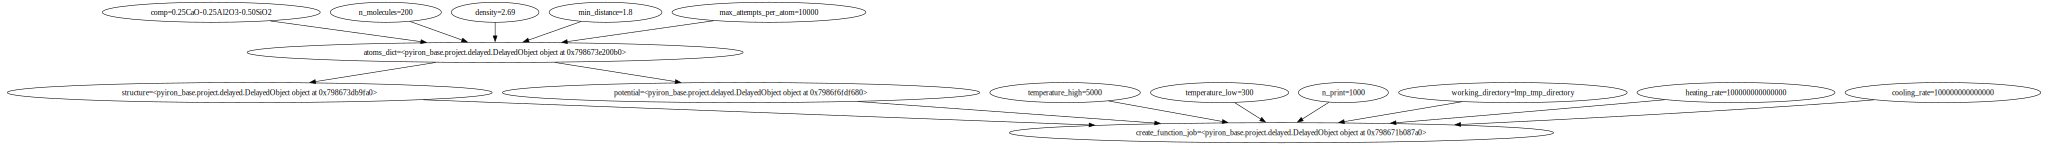

In [5]:
delayed.draw()

In [6]:
result = delayed.pull()

/home/leoteo/miniforge3/envs/pyiron-glass/lib/python3.12/site-packages/h5io/_h5io.py:72: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['Name', 'Filename', 'Model', 'Species', 'Config'], dtype='object')]

  data.to_hdf(file_name, key=rootpath)
/home/leoteo/miniforge3/envs/pyiron-glass/lib/python3.12/site-packages/h5io/_h5io.py:78: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['Name', 'Filename', 'Model', 'Species', 'Config'], dtype='object')]

  data.to_hdf(fname, key=rootpath)


The job melt_quench_simulation_8d83960332a0e5ff937314e01adb1623 was saved and received the ID: 7


/home/leoteo/miniforge3/envs/pyiron-glass/lib/python3.12/site-packages/h5io/_h5io.py:72: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['Name', 'Filename', 'Model', 'Species', 'Config'], dtype='object')]

  data.to_hdf(file_name, key=rootpath)
/home/leoteo/miniforge3/envs/pyiron-glass/lib/python3.12/site-packages/h5io/_h5io.py:78: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['Name', 'Filename', 'Model', 'Species', 'Config'], dtype='object')]

  data.to_hdf(fname, key=rootpath)


In [ ]:
# NBVAL_CHECK_OUTPUT
print(f"{np.mean(result["temperature"]):.1f} K")

301.015 K


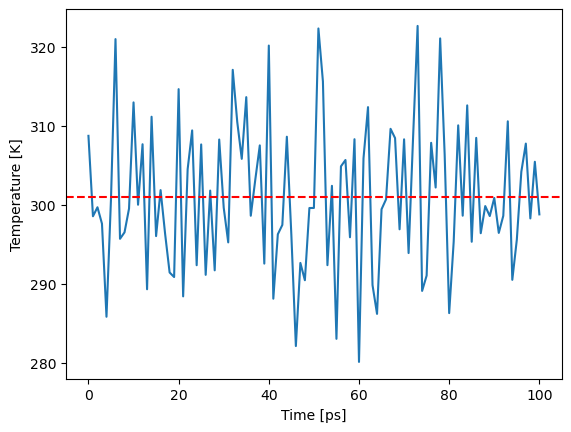

In [9]:
plt.plot(result["steps"]*1e-3, result["temperature"])
plt.axhline(np.mean(result["temperature"]), color="red", linestyle="--")
plt.xlabel("Time [ps]")
plt.ylabel("Temperature [K]");